🧪 Phase 3 Sanity Checks - Quick Validation
1. Label Alignment & Data Integrity Check

Shape: (357, 32)
NaNs: 0
Label counts:
 disease
ALL        124
AML         96
CLL         85
UNKNOWN     33
CML         11
Healthy      8
Name: count, dtype: int64
Label mapping: {'ALL': 0, 'AML': 1, 'CLL': 2, 'CML': 3, 'UNKNOWN': 4, 'Healthy': 5}
⚠️ Tiny classes (n<10):
 disease
Healthy    8
Name: count, dtype: int64
Classes: 6, uniform-chance=0.167, majority-baseline=0.347


c:\Users\T470\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:12:56] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\T470\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:12:58] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\T470\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:13:00] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\T470\anaconda3\Lib\site-packages\xgbo

XGBoost CV accuracy: 0.831 ± 0.051


c:\Users\T470\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:13:06] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\T470\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:13:08] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\T470\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:13:10] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\T470\anaconda3\Lib\site-packages\xgbo

Shuffled accuracy: 0.269 ± 0.016
Signal: 0.562


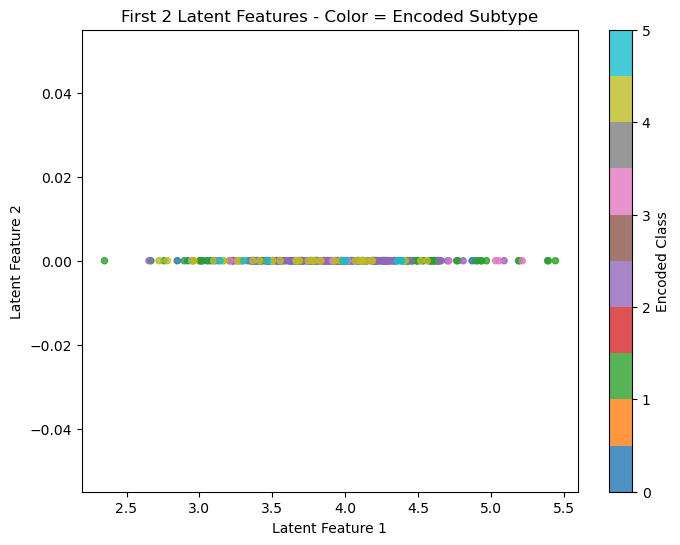


✅ Quick sanity verdict: PASS
Label mapping for reference: {'ALL': 0, 'AML': 1, 'CLL': 2, 'CML': 3, 'UNKNOWN': 4, 'Healthy': 5}


In [12]:
# Phase 3 quick sanity (FIXED - numeric labels)
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# --- load
df = pd.read_csv("../data/processed/leukemia_latent_features.csv", index_col=0)
print("Shape:", df.shape)
print("NaNs:", df.isnull().sum().sum())
print("Label counts:\n", df['disease'].value_counts())

# Convert string labels to numeric
label_mapping = {label: i for i, label in enumerate(df['disease'].unique())}
reverse_mapping = {i: label for label, i in label_mapping.items()}
df['disease_encoded'] = df['disease'].map(label_mapping)

print("Label mapping:", label_mapping)

# quick warn on tiny classes
small = df['disease'].value_counts()[df['disease'].value_counts() < 10]
if len(small):
    print("⚠️ Tiny classes (n<10):\n", small)

# features / labels
X = df.iloc[:, :30].values
y = df['disease_encoded'].values
n_classes = len(np.unique(y))
chance_uniform = 1.0 / n_classes
majority_baseline = df['disease_encoded'].value_counts().iloc[0] / len(df)
print(f"Classes: {n_classes}, uniform-chance={chance_uniform:.3f}, majority-baseline={majority_baseline:.3f}")

# Manual cross-validation 
def manual_stratified_cv(X, y, clf, n_splits=5):
    """Manual stratified cross-validation"""
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    fold_size = len(X) // n_splits
    
    scores = []
    for i in range(n_splits):
        test_start = i * fold_size
        test_end = (i + 1) * fold_size
        test_idx = indices[test_start:test_end]
        train_idx = np.concatenate([indices[:test_start], indices[test_end:]])
        
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        accuracy = np.mean(y_pred == y_test)
        scores.append(accuracy)
    
    return np.array(scores)

# model
clf = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42
)

# Manual CV
scores_acc = manual_stratified_cv(X, y, clf, n_splits=5)
print(f"XGBoost CV accuracy: {scores_acc.mean():.3f} ± {scores_acc.std():.3f}")

# Manual shuffle test
def manual_shuffle_test(X, y, clf, n_splits=5, n_repeats=5):
    shuf_scores = []
    for repeat in range(n_repeats):
        y_shuffled = y.copy()
        np.random.shuffle(y_shuffled)
        scores = manual_stratified_cv(X, y_shuffled, clf, n_splits)
        shuf_scores.append(scores.mean())
    return np.array(shuf_scores)

shuf_scores = manual_shuffle_test(X, y, clf)
print(f"Shuffled accuracy: {shuf_scores.mean():.3f} ± {shuf_scores.std():.3f}")
print(f"Signal: {scores_acc.mean() - shuf_scores.mean():.3f}")

# Simple scatter plot (first 2 features)
plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=y, s=20, alpha=0.8, cmap='tab10')
plt.title("First 2 Latent Features - Color = Encoded Subtype")
plt.xlabel("Latent Feature 1")
plt.ylabel("Latent Feature 2")
plt.colorbar(label='Encoded Class')
plt.show()

# PASS criteria
passed = (scores_acc.mean() > shuf_scores.mean() + 0.10) and (scores_acc.mean() > majority_baseline)
print("\n✅ Quick sanity verdict:", "PASS" if passed else "FAIL")
print("Label mapping for reference:", label_mapping)